In [2]:
import pandas as pd
import numpy as np

In [8]:
mcclelland = pd.read_excel("mcclelland_lake_all_parameters_master.xlsx")
shipyard = pd.read_excel("shipyard_lake_all_parameters_master (1).xlsx")

In [9]:
mcclelland

,Sampling Timestamp,Value,Unit Symbol,RDL,Method,Laboratory,Site Name,Station Name,Parameter
0,2003-09-14 03:00:00,18.200,mg/l,0.100000,1849,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Calcium Dissolved
1,2003-09-14 03:00:00,0.400,µg/l,0.000100,1849,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Copper Dissolved
2,2003-09-14 07:00:00,0.200,µg/l,0.000050,1847,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Vanadium Total Recoverable
3,2003-09-14 08:00:00,5.200,µg/l,0.002000,1847,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Aluminum Total Recoverable
4,2003-09-14 09:00:00,0.020,µg/l,0.000006,1849,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Lead Dissolved
...,...,...,...,...,...,...,...,...,...
162,2017-03-14 11:00:00,0.848,µg/l,0.000008,1847,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),MCCLELLAND LAKE,COMPOSITE,Nickel Total Recoverable
163,2017-03-14 11:00:00,0.016,mg/l,0.003000,443,"MAXXAM (CHEMEX) LABS ALBERTA INC., CALGARY, AL...",MCCLELLAND LAKE,COMPOSITE,Phosphorus Total
164,2017-03-14 11:00:00,0.130,µg/l,0.000020,1849,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),MCCLELLAND LAKE,COMPOSITE,Vanadium Dissolved
165,2017-03-14 12:00:00,0.820,µg/l,0.000130,1849,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),MCCLELLAND LAKE,COMPOSITE,Aluminum Dissolved


In [10]:
shipyard

,Sampling Timestamp,Value,Unit Symbol,RDL,Method,Laboratory,Site Name,Station Name,Parameter
0,2003-07-21 03:00:00,7.800,µg/l,0.002000,1847,Alberta Research Council,SHIPYARD LAKE,COMPOSITE,Aluminum Total Recoverable
1,2003-07-21 03:00:00,0.100,µg/l,0.000100,1849,Alberta Research Council,SHIPYARD LAKE,COMPOSITE,Copper Dissolved
2,2003-07-21 10:00:00,1.500,µg/l,0.001000,1849,Alberta Research Council,SHIPYARD LAKE,COMPOSITE,Aluminum Dissolved
3,2003-07-21 10:00:00,49.100,mg/l,0.100000,1847,Alberta Research Council,SHIPYARD LAKE,COMPOSITE,Calcium Total
4,2003-07-21 10:00:00,0.200,µg/l,0.000100,1847,Alberta Research Council,SHIPYARD LAKE,COMPOSITE,Copper Total Recoverable
...,...,...,...,...,...,...,...,...,...
181,2016-09-20 11:00:00,0.350,µg/l,0.000010,1847,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),SHIPYARD LAKE,COMPOSITE,Vanadium Total Recoverable
182,2016-09-20 12:00:00,21.300,mg/l,0.030000,1849,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),SHIPYARD LAKE,COMPOSITE,Calcium Dissolved
183,2016-09-20 12:00:00,0.043,µg/l,0.000003,1847,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),SHIPYARD LAKE,COMPOSITE,Lead Total Recoverable
184,2016-09-20 12:00:00,0.025,mg/l,0.003000,443,"MAXXAM (CHEMEX) LABS ALBERTA INC., CALGARY, AL...",SHIPYARD LAKE,COMPOSITE,Phosphorus Total


In [12]:
df= pd.concat([mcclelland,shipyard])

In [21]:
unit = df["Unit Symbol"] == "mg/l"
df.loc[unit, "Value"] = df.loc[unit, "Value"]*1000
df.loc[unit, "Unit Symbol"] = "µg/l"

df

,Sampling Timestamp,Value,Unit Symbol,RDL,Method,Laboratory,Site Name,Station Name,Parameter
0,2003-09-14 03:00:00,18200.000,µg/l,0.100000,1849,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Calcium Dissolved
1,2003-09-14 03:00:00,0.400,µg/l,0.000100,1849,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Copper Dissolved
2,2003-09-14 07:00:00,0.200,µg/l,0.000050,1847,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Vanadium Total Recoverable
3,2003-09-14 08:00:00,5.200,µg/l,0.002000,1847,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Aluminum Total Recoverable
4,2003-09-14 09:00:00,0.020,µg/l,0.000006,1849,Alberta Research Council,MCCLELLAND LAKE,COMPOSITE,Lead Dissolved
...,...,...,...,...,...,...,...,...,...
181,2016-09-20 11:00:00,0.350,µg/l,0.000010,1847,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),SHIPYARD LAKE,COMPOSITE,Vanadium Total Recoverable
182,2016-09-20 12:00:00,21300.000,µg/l,0.030000,1849,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),SHIPYARD LAKE,COMPOSITE,Calcium Dissolved
183,2016-09-20 12:00:00,0.043,µg/l,0.000003,1847,AITF-EAS (ENVIRONMENTAL ANALYTICAL SERVICES),SHIPYARD LAKE,COMPOSITE,Lead Total Recoverable
184,2016-09-20 12:00:00,25.000,µg/l,0.003000,443,"MAXXAM (CHEMEX) LABS ALBERTA INC., CALGARY, AL...",SHIPYARD LAKE,COMPOSITE,Phosphorus Total


In [22]:
df_wide = df.pivot_table(
    index=["Sampling Timestamp", "Site Name"],  # rows stay the same
    columns="Parameter",                        # turn Parameter into columns
    values="Value"                              # fill columns with Value
).reset_index()
    

In [42]:
df_wide["Unit Symbol"] = "µg/l"
df_wide["Distance Group"] = "Mid-Fields"
df_wide

Parameter,Sampling Timestamp,Site Name,Aluminum Dissolved,Aluminum Total Recoverable,Calcium Dissolved,Calcium Total,Copper Dissolved,Copper Total Recoverable,Lead Dissolved,Lead Total Recoverable,Nickel Dissolved,Nickel Total Recoverable,Nitrogen Total,Phosphorus Total,Phosphorus Total Dissolved,Vanadium Dissolved,Vanadium Total Recoverable,Unit Symbol,Distance Group
0,2003-07-21 03:00:00,SHIPYARD LAKE,NaN,7.8,NaN,NaN,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,µg/l,Mid-Fields
1,2003-07-21 10:00:00,SHIPYARD LAKE,1.50,NaN,NaN,49100.0,NaN,0.20,NaN,NaN,NaN,NaN,700.0,NaN,NaN,0.20,NaN,µg/l,Mid-Fields
2,2003-07-21 11:00:00,SHIPYARD LAKE,NaN,NaN,NaN,NaN,NaN,NaN,0.100,NaN,0.100,0.100,NaN,NaN,NaN,NaN,0.30,µg/l,Mid-Fields
3,2003-07-21 12:00:00,SHIPYARD LAKE,NaN,NaN,47600.0,NaN,NaN,NaN,NaN,0.100,NaN,NaN,NaN,13.0,6.0,NaN,NaN,µg/l,Mid-Fields
4,2003-09-14 03:00:00,MCCLELLAND LAKE,NaN,NaN,18200.0,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,µg/l,Mid-Fields
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2017-03-14 07:00:00,MCCLELLAND LAKE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.13,µg/l,Mid-Fields
118,2017-03-14 08:00:00,MCCLELLAND LAKE,NaN,8.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,µg/l,Mid-Fields
119,2017-03-14 09:00:00,MCCLELLAND LAKE,NaN,NaN,NaN,NaN,NaN,NaN,0.004,NaN,NaN,NaN,1100.0,NaN,5.8,NaN,NaN,µg/l,Mid-Fields
120,2017-03-14 11:00:00,MCCLELLAND LAKE,NaN,NaN,NaN,33100.0,NaN,NaN,NaN,0.035,0.068,0.848,NaN,16.0,NaN,0.13,NaN,µg/l,Mid-Fields


In [25]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Sampling Timestamp          122 non-null    datetime64[ns]
 1   Site Name                   122 non-null    object        
 2   Aluminum Dissolved          23 non-null     float64       
 3   Aluminum Total Recoverable  23 non-null     float64       
 4   Calcium Dissolved           23 non-null     float64       
 5   Calcium Total               23 non-null     float64       
 6   Copper Dissolved            23 non-null     float64       
 7   Copper Total Recoverable    23 non-null     float64       
 8   Lead Dissolved              23 non-null     float64       
 9   Lead Total Recoverable      23 non-null     float64       
 10  Nickel Dissolved            23 non-null     float64       
 11  Nickel Total Recoverable    23 non-null     float64       

In [26]:
df_wide.describe()

Parameter,Sampling Timestamp,Aluminum Dissolved,Aluminum Total Recoverable,Calcium Dissolved,Calcium Total,Copper Dissolved,Copper Total Recoverable,Lead Dissolved,Lead Total Recoverable,Nickel Dissolved,Nickel Total Recoverable,Nitrogen Total,Phosphorus Total,Phosphorus Total Dissolved,Vanadium Dissolved,Vanadium Total Recoverable
count,122,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,31.000000,23.000000,23.000000,23.000000,23.00000
mean,2011-03-01 00:13:46.229508096,1.586522,21.822609,30021.739130,31273.913043,0.222130,0.258826,0.048665,0.069952,0.149565,0.207696,929.741935,19.343478,6.926087,0.154991,0.21983
min,2003-07-21 03:00:00,0.130000,2.030000,12700.000000,12700.000000,0.100000,0.100000,0.004000,0.006000,0.006000,0.008000,300.000000,7.000000,2.100000,0.050000,0.05210
25%,2007-08-01 11:30:00,1.000000,5.660000,18800.000000,20550.000000,0.100000,0.128000,0.006000,0.014050,0.060000,0.060000,800.500000,12.950000,3.550000,0.100000,0.12500
50%,2011-09-11 06:30:00,1.050000,11.800000,25400.000000,25700.000000,0.160000,0.220000,0.020000,0.043000,0.100000,0.100000,951.000000,14.300000,5.900000,0.140000,0.20000
75%,2014-09-05 08:45:00,1.715000,18.350000,39850.000000,40900.000000,0.290000,0.348500,0.100000,0.100000,0.135000,0.221500,1050.000000,21.400000,7.500000,0.200000,0.26250
max,2017-03-14 12:00:00,6.570000,190.000000,52100.000000,54800.000000,0.626000,0.633000,0.165000,0.323000,0.675000,0.848000,1360.000000,64.900000,17.700000,0.380000,0.65700
std,NaN,1.407375,38.523066,12398.568705,12831.290497,0.136068,0.156602,0.048930,0.073730,0.170739,0.245424,183.781930,12.580462,4.521988,0.074398,0.14085


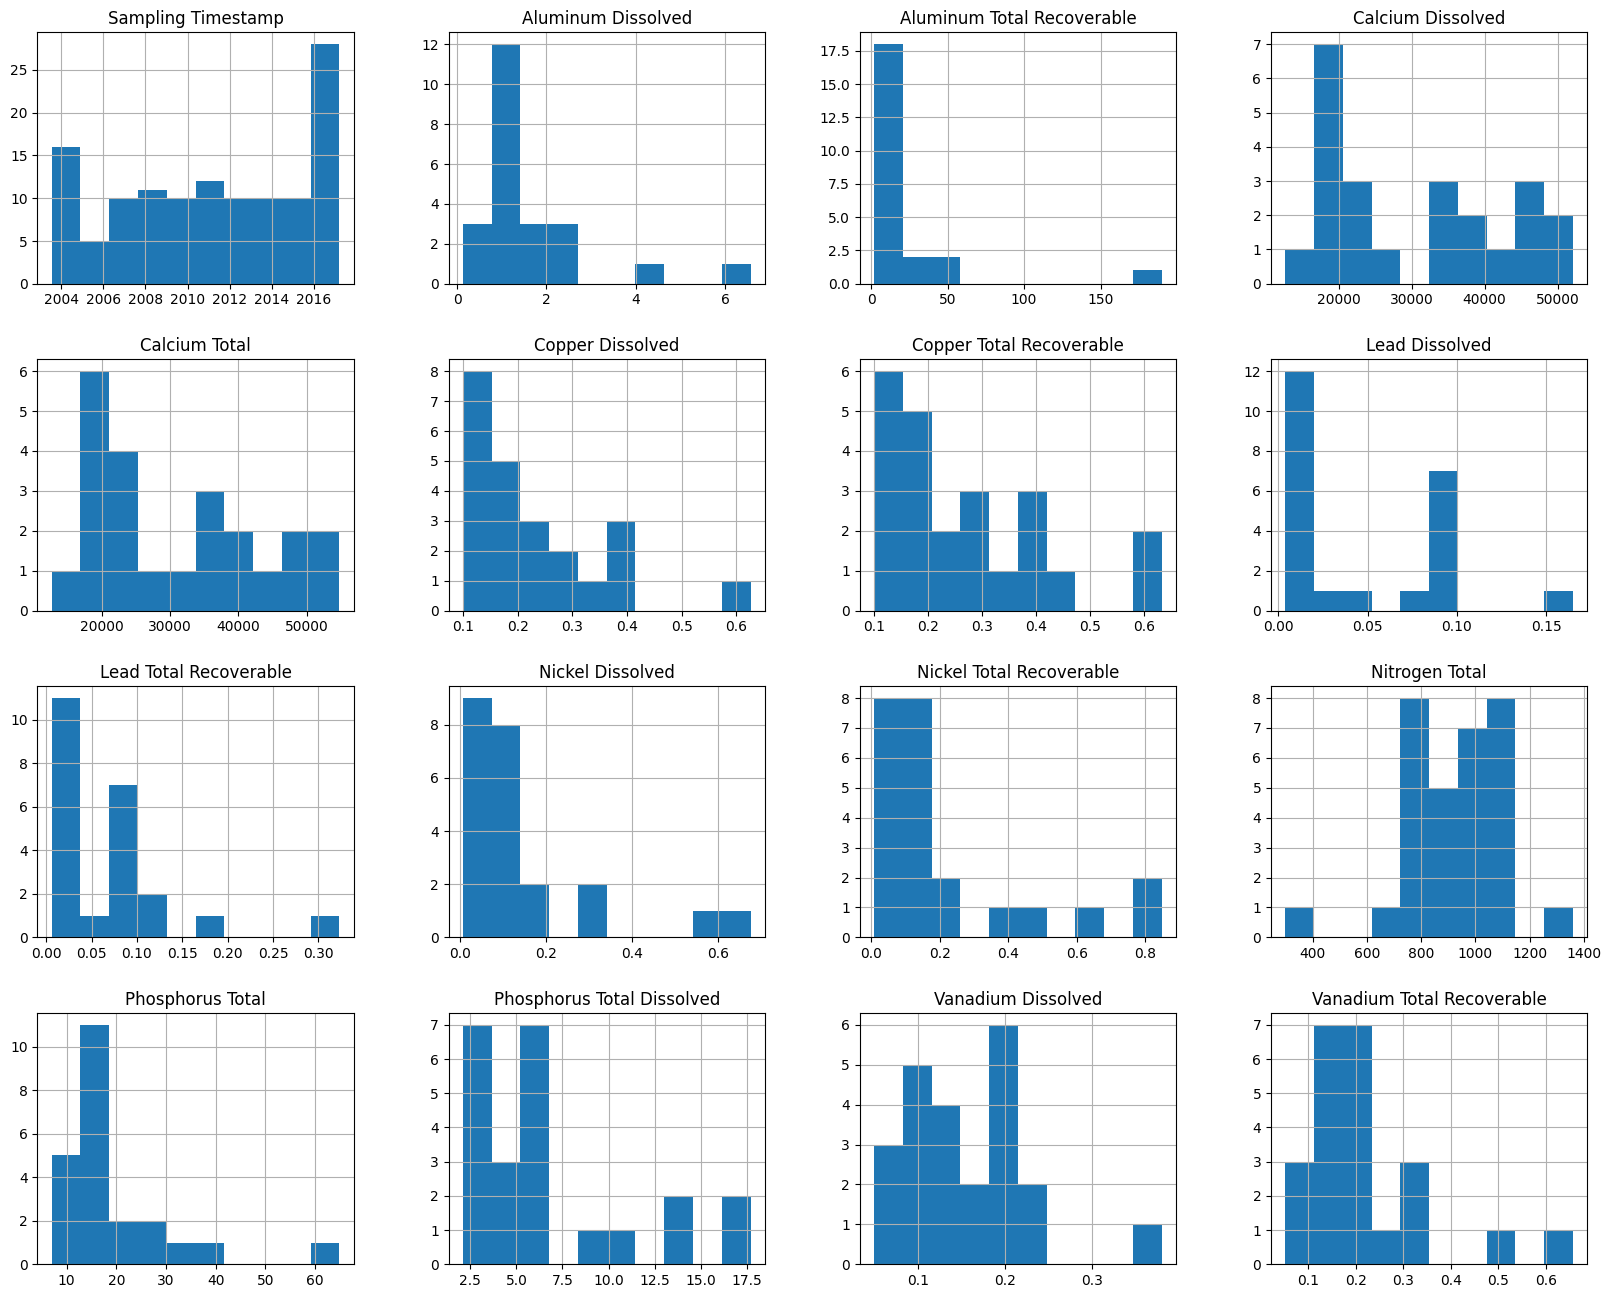

In [33]:
import matplotlib.pyplot as plt
df_wide.hist(figsize=(20,16))
plt.show()

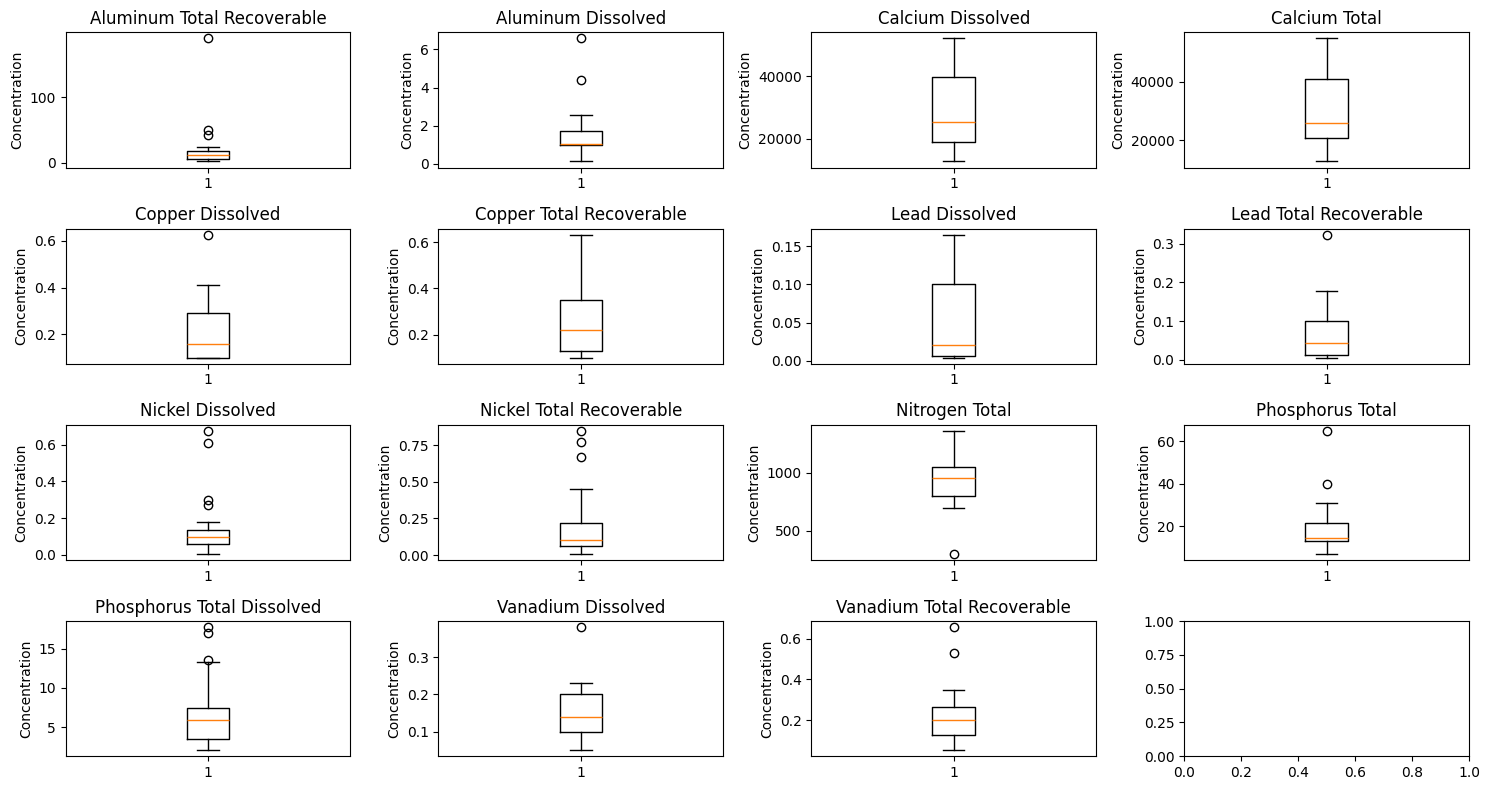

In [45]:
import matplotlib.pyplot as plt

chem_cols = [
    "Aluminum Total Recoverable",
    "Aluminum Dissolved",
    "Calcium Dissolved",
    "Calcium Total",
    "Copper Dissolved",
    "Copper Total Recoverable",
    "Lead Dissolved",
    "Lead Total Recoverable",
    "Nickel Dissolved",
    "Nickel Total Recoverable",
    "Nitrogen Total",
    "Phosphorus Total",
    "Phosphorus Total Dissolved",
    "Vanadium Dissolved",
    "Vanadium Total Recoverable"
]

fig, axes = plt.subplots(4, 4, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(chem_cols):
    axes[i].boxplot(df_wide[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel("Concentration")

plt.tight_layout()
plt.show()

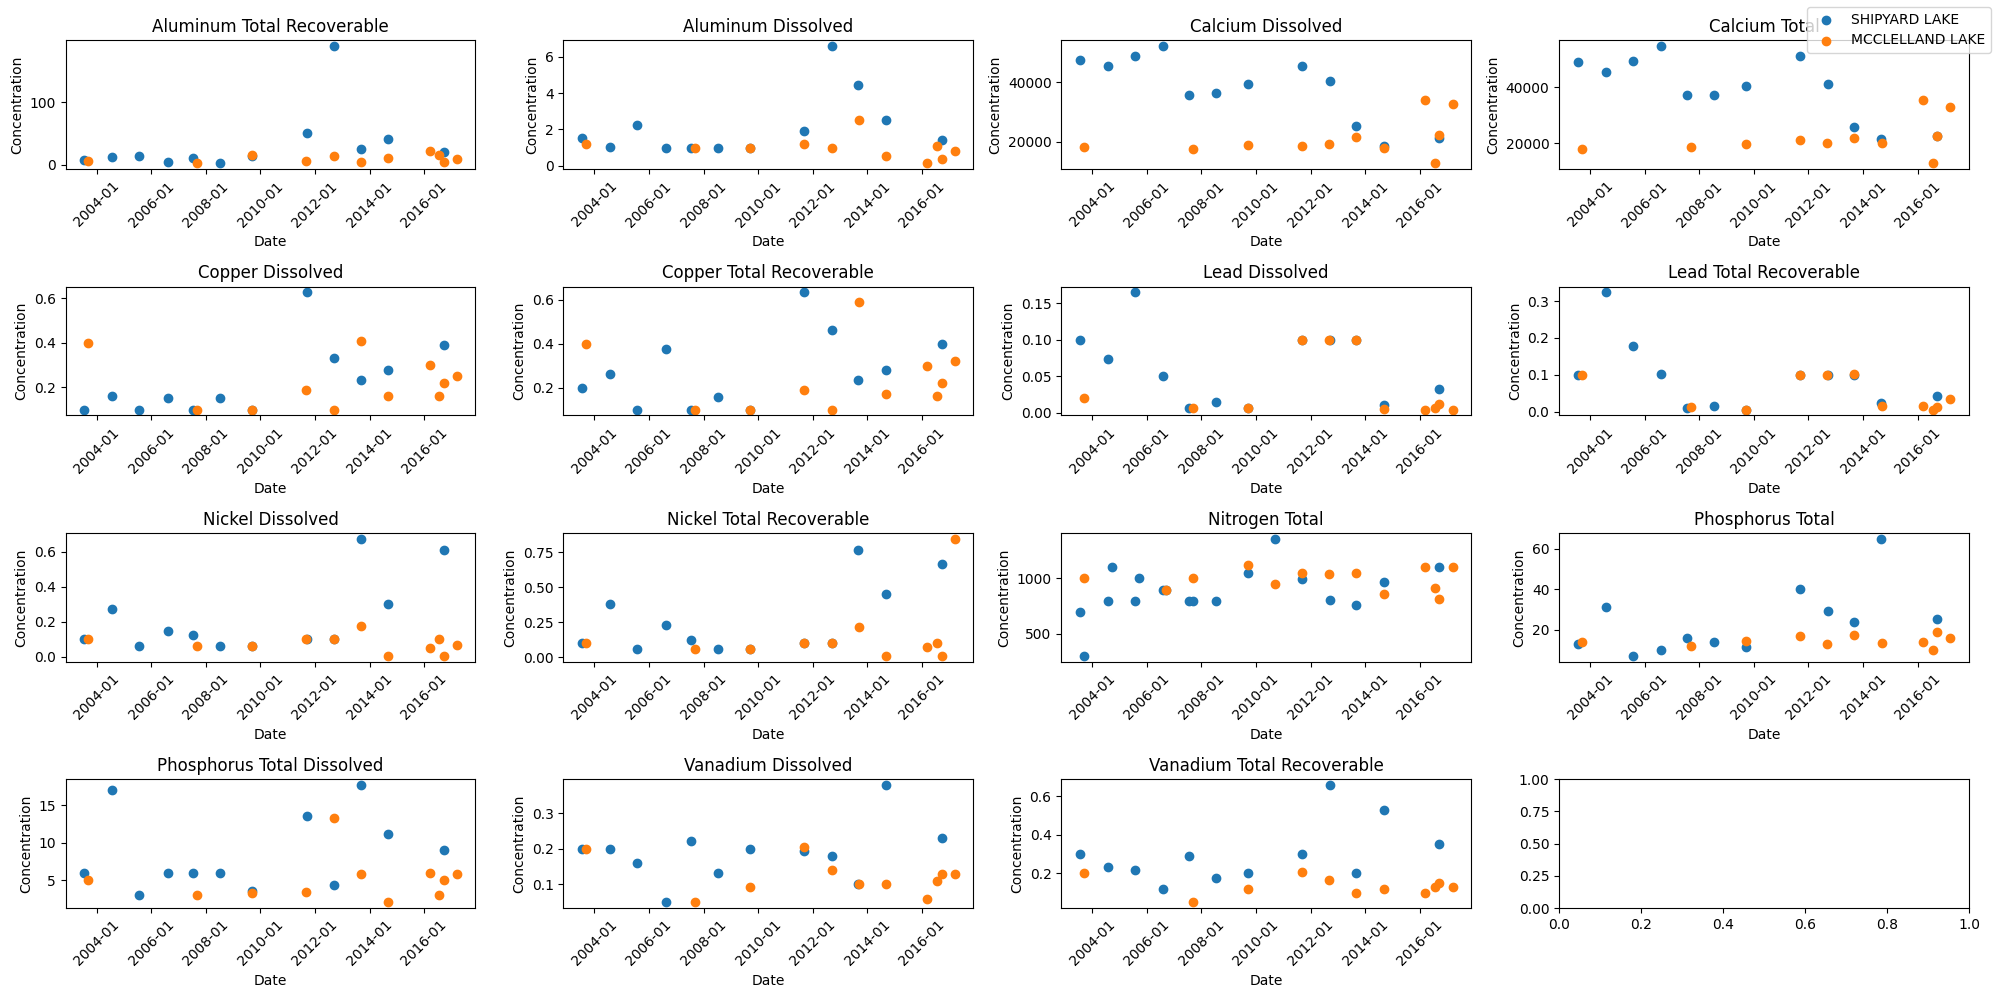

In [46]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 4, figsize=(20,10))
axes = axes.flatten()

for i, col in enumerate(chem_cols):
    ax = axes[i]
    
    for lake in df_wide["Site Name"].unique():
        lake_data = df_wide[df_wide["Site Name"] == lake]

        ax.scatter(
            lake_data["Sampling Timestamp"],
            lake_data[col],
            label=lake
            
        )
       

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    
    ax.set_title(col)
    ax.set_xlabel("Date")
    ax.set_ylabel("Concentration")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()

In [1]:
df_wide.to_csv("MidLake_Data.csv", index= False)

NameError: name 'df_wide' is not defined